# V5.6 Direct Taste-Vector Refinement

Проверяем отдельный чистый вариант: после soft-stop marker не останавливаемся и не уходим в zone refinement, а делаем контролируемые прямые шаги в сторону предполагаемого вектора вкуса (`z_blend`, `z_model`, trust-region).

In [18]:
from pathlib import Path
import sys, importlib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from personalization.plotting import use_article_style
from personalization.batch_eval import win_rates_vs_baseline
import personalization.direct_taste_vector_v56 as v56
importlib.reload(v56)

use_article_style()
PROJECT_ROOT

WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization')

## Настройки запуска

In [21]:
DATASET_PATH = PROJECT_ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
SAMPLE_PER_MODE = None  # None или 0 — полный датасет
N_STEPS = 25
PREFIX = 'article_v56_direct_taste_vector_refinement'

dataset = pd.read_csv(DATASET_PATH)

if SAMPLE_PER_MODE is None or int(SAMPLE_PER_MODE) <= 0:
    dataset_eval = dataset.copy().reset_index(drop=True)
else:
    parts = []
    for _, group in dataset.groupby('target_mode'):
        parts.append(group.sample(n=min(int(SAMPLE_PER_MODE), len(group)), random_state=42))
    dataset_eval = pd.concat(parts, axis=0).reset_index(drop=True)

dataset_eval.groupby('target_mode').size()

target_mode
archetype8d    100
random8d       100
semantic4d     100
semantic6d     100
dtype: int64

## Запуск эксперимента

In [22]:
sessions, steps, curves = v56.run_v56_comparison_on_dataset(
    dataset=dataset_eval,
    n_steps=N_STEPS,
)

summary = v56.summarize_v56_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = v56.source_usage_table_v56(steps)
post_marker_source_usage = v56.post_marker_source_usage_table_v56(steps, target_mode='archetype8d')
step_budget = v56.phase_step_budget_table_v56(sessions, target_mode='archetype8d')

direct_selection = v56.direct_selection_table_v56(steps, target_mode='archetype8d')
direct_diagnostics = v56.direct_vector_diagnostics_table_v56(steps, target_mode='archetype8d')


## Сохранение таблиц

In [23]:
metrics_dir = PROJECT_ROOT / 'outputs' / 'metrics'
table_dir = PROJECT_ROOT / 'outputs' / 'tables'
fig_dir = PROJECT_ROOT / 'outputs' / 'figures'
metrics_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

v56.save_v56_outputs(
    sessions, steps, summary, win_rates, source_usage, step_budget, metrics_dir,
    prefix=PREFIX, post_marker_source_usage=post_marker_source_usage,
)
step_budget.to_csv(table_dir / f'{PREFIX}_step_budget_archetype8d.csv', index=False)
post_marker_source_usage.to_csv(table_dir / f'{PREFIX}_post_marker_source_usage_archetype8d.csv', index=False)
direct_selection.to_csv(table_dir / f'{PREFIX}_direct_selection_archetype8d.csv', index=False)
direct_diagnostics.to_csv(table_dir / f'{PREFIX}_direct_vector_diagnostics_archetype8d.csv', index=False)

metrics_dir, fig_dir, table_dir

(WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization/outputs/metrics'),
 WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization/outputs/figures'),
 WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization/outputs/tables'))

## Быстрый просмотр ключевых таблиц

In [24]:
summary_view = summary[summary['target_mode'].eq('archetype8d') & summary['strategy'].isin([
    'semantic_active_v21',
    v56.V54_STRATEGY_NAME,
    v56.V55_MIXED_STRATEGY_NAME,
    v56.V56_BLEND_STRATEGY_NAME,
    v56.V56_PM_STRATEGY_NAME,
    v56.V56_TRUST_STRATEGY_NAME,
    'candidate_pool_active',
])].copy()

summary_view[[
    'strategy',
    'mean_recommended_stop_step',
    'mean_distance_at_recommended_stop',
    'mean_final_distance',
    'mean_extra_gain_after_stop',
    'aggregate_retained_quality_at_stop_pct',
    'mean_steps_before_recommendation',
    'mean_steps_after_recommendation',
]].sort_values('mean_final_distance')

,strategy,mean_recommended_stop_step,mean_distance_at_recommended_stop,mean_final_distance,mean_extra_gain_after_stop,aggregate_retained_quality_at_stop_pct,mean_steps_before_recommendation,mean_steps_after_recommendation
5,semantic_active_soft_stop_monitor_v54,15.1,0.448856,0.383889,0.064968,90.960973,15.1,9.9
6,semantic_active_v21,NaN,NaN,0.383889,NaN,NaN,25.0,0.0
1,direct_blend_refinement_v56,15.1,0.448856,0.405226,0.043630,93.744001,15.1,9.9
7,trust_region_direct_refinement_v56,15.1,0.448856,0.405226,0.043630,93.744001,15.1,9.9
2,direct_pm_refinement_v56,15.1,0.448856,0.405226,0.043630,93.744011,15.1,9.9
3,phase_mixed_refinement_full_budget_v55,15.1,0.448856,0.409360,0.039496,94.302956,15.1,9.9
0,candidate_pool_active,NaN,NaN,0.492151,NaN,NaN,25.0,0.0


In [25]:
direct_selection

,target_mode,strategy,selected_role,count,share
0,archetype8d,direct_blend_refinement_v56,anchor_selected,693,0.7
1,archetype8d,direct_blend_refinement_v56,direct_candidate_selected,297,0.3
2,archetype8d,direct_pm_refinement_v56,anchor_selected,693,0.7
3,archetype8d,direct_pm_refinement_v56,direct_candidate_selected,297,0.3
4,archetype8d,trust_region_direct_refinement_v56,anchor_selected,693,0.7
5,archetype8d,trust_region_direct_refinement_v56,direct_candidate_selected,297,0.3


In [26]:
direct_diagnostics[[
    'strategy',
    'n_post_marker_questions',
    'direct_selected_rate',
    'mean_delta_pm_norm',
    'mean_delta_blend_norm',
    'mean_delta_pm_blend_cosine',
    'mean_direction_cosine_to_blend_delta',
    'mean_direction_cosine_to_pm_delta',
    'mean_trust_mask_mean',
    'mean_scale',
    'mean_pair_distance',
]].sort_values('strategy')

,strategy,n_post_marker_questions,direct_selected_rate,mean_delta_pm_norm,mean_delta_blend_norm,mean_delta_pm_blend_cosine,mean_direction_cosine_to_blend_delta,mean_direction_cosine_to_pm_delta,mean_trust_mask_mean,mean_scale,mean_pair_distance
0,direct_blend_refinement_v56,990,0.3,0.05233,0.015699,1.0,1.000000,1.000000,1.0000,0.24,0.239999
1,direct_pm_refinement_v56,990,0.3,0.05233,0.015699,1.0,1.000000,1.000000,1.0000,0.24,0.240000
2,trust_region_direct_refinement_v56,990,0.3,0.05233,0.015699,1.0,0.960501,0.960501,0.7625,0.24,0.239999


## Графики

Графики строятся, сохраняются в `outputs/figures` и сразу отображаются прямо в ноутбуке.

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_convergence_archetype8d.png


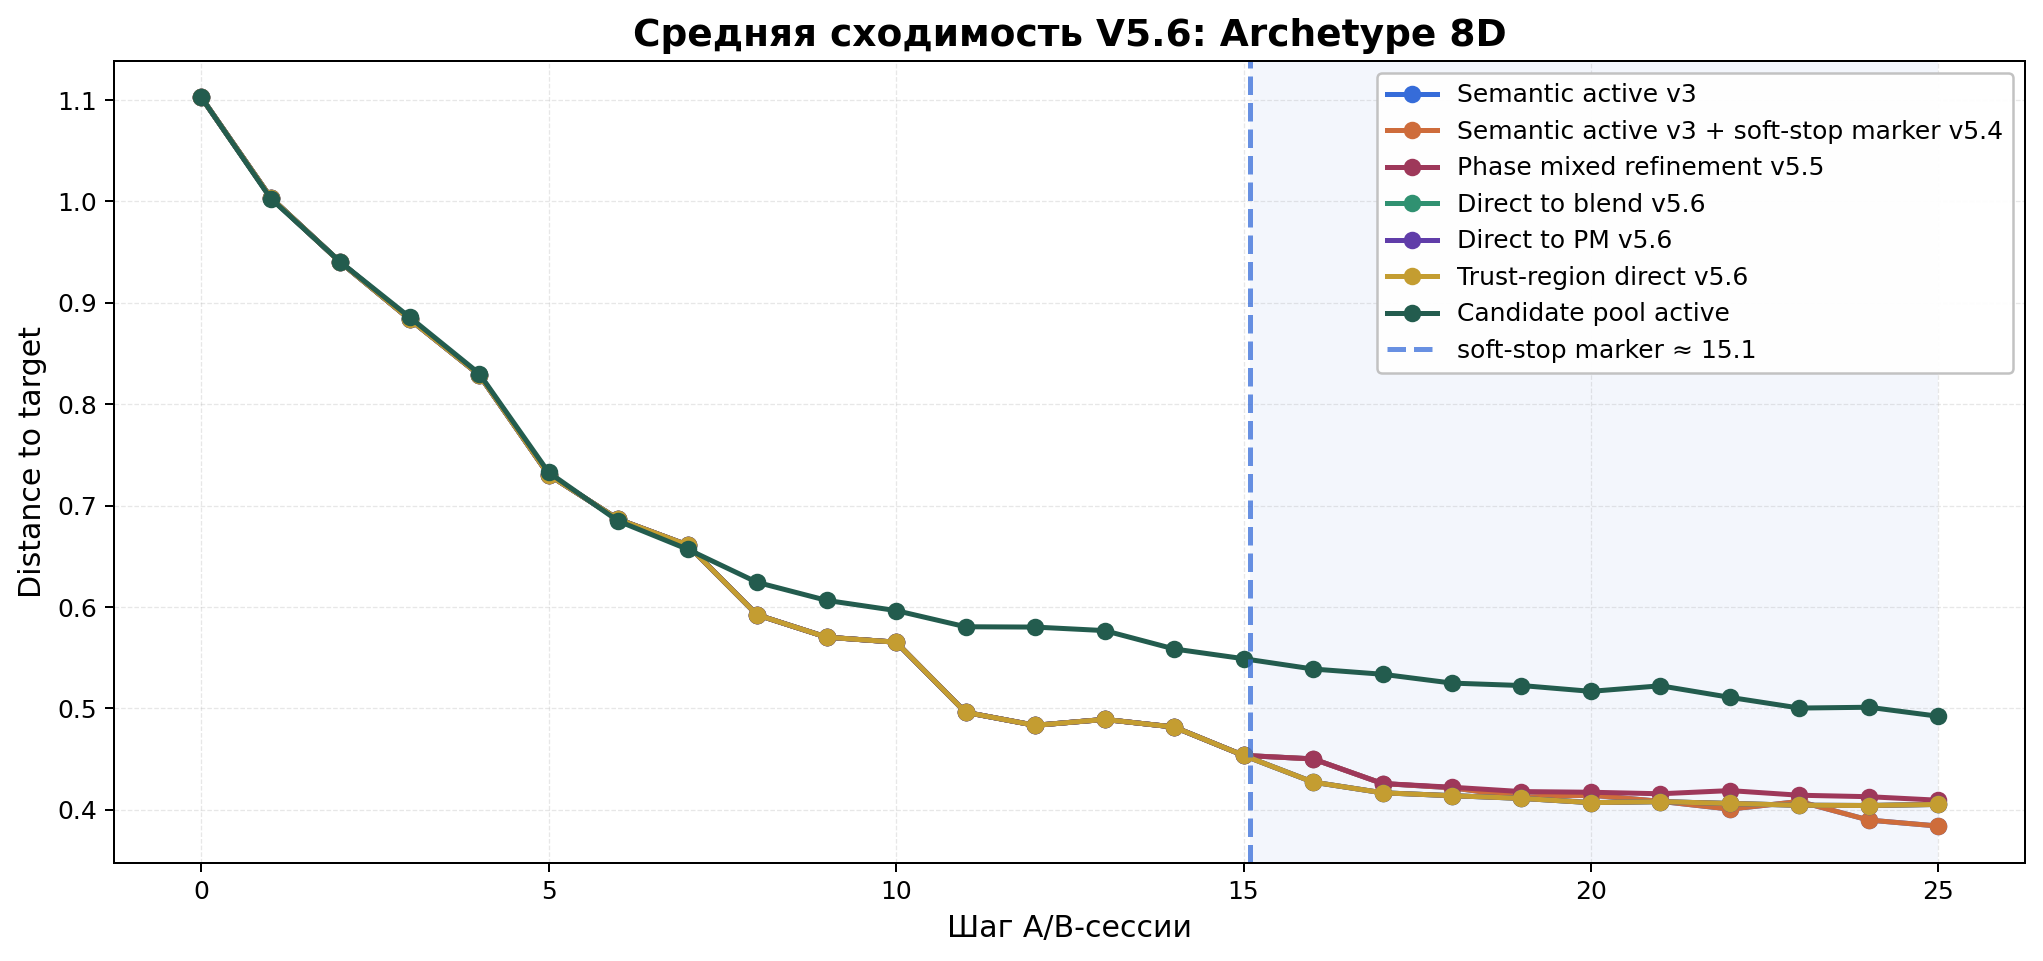

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_mean_final_distance_by_target.png


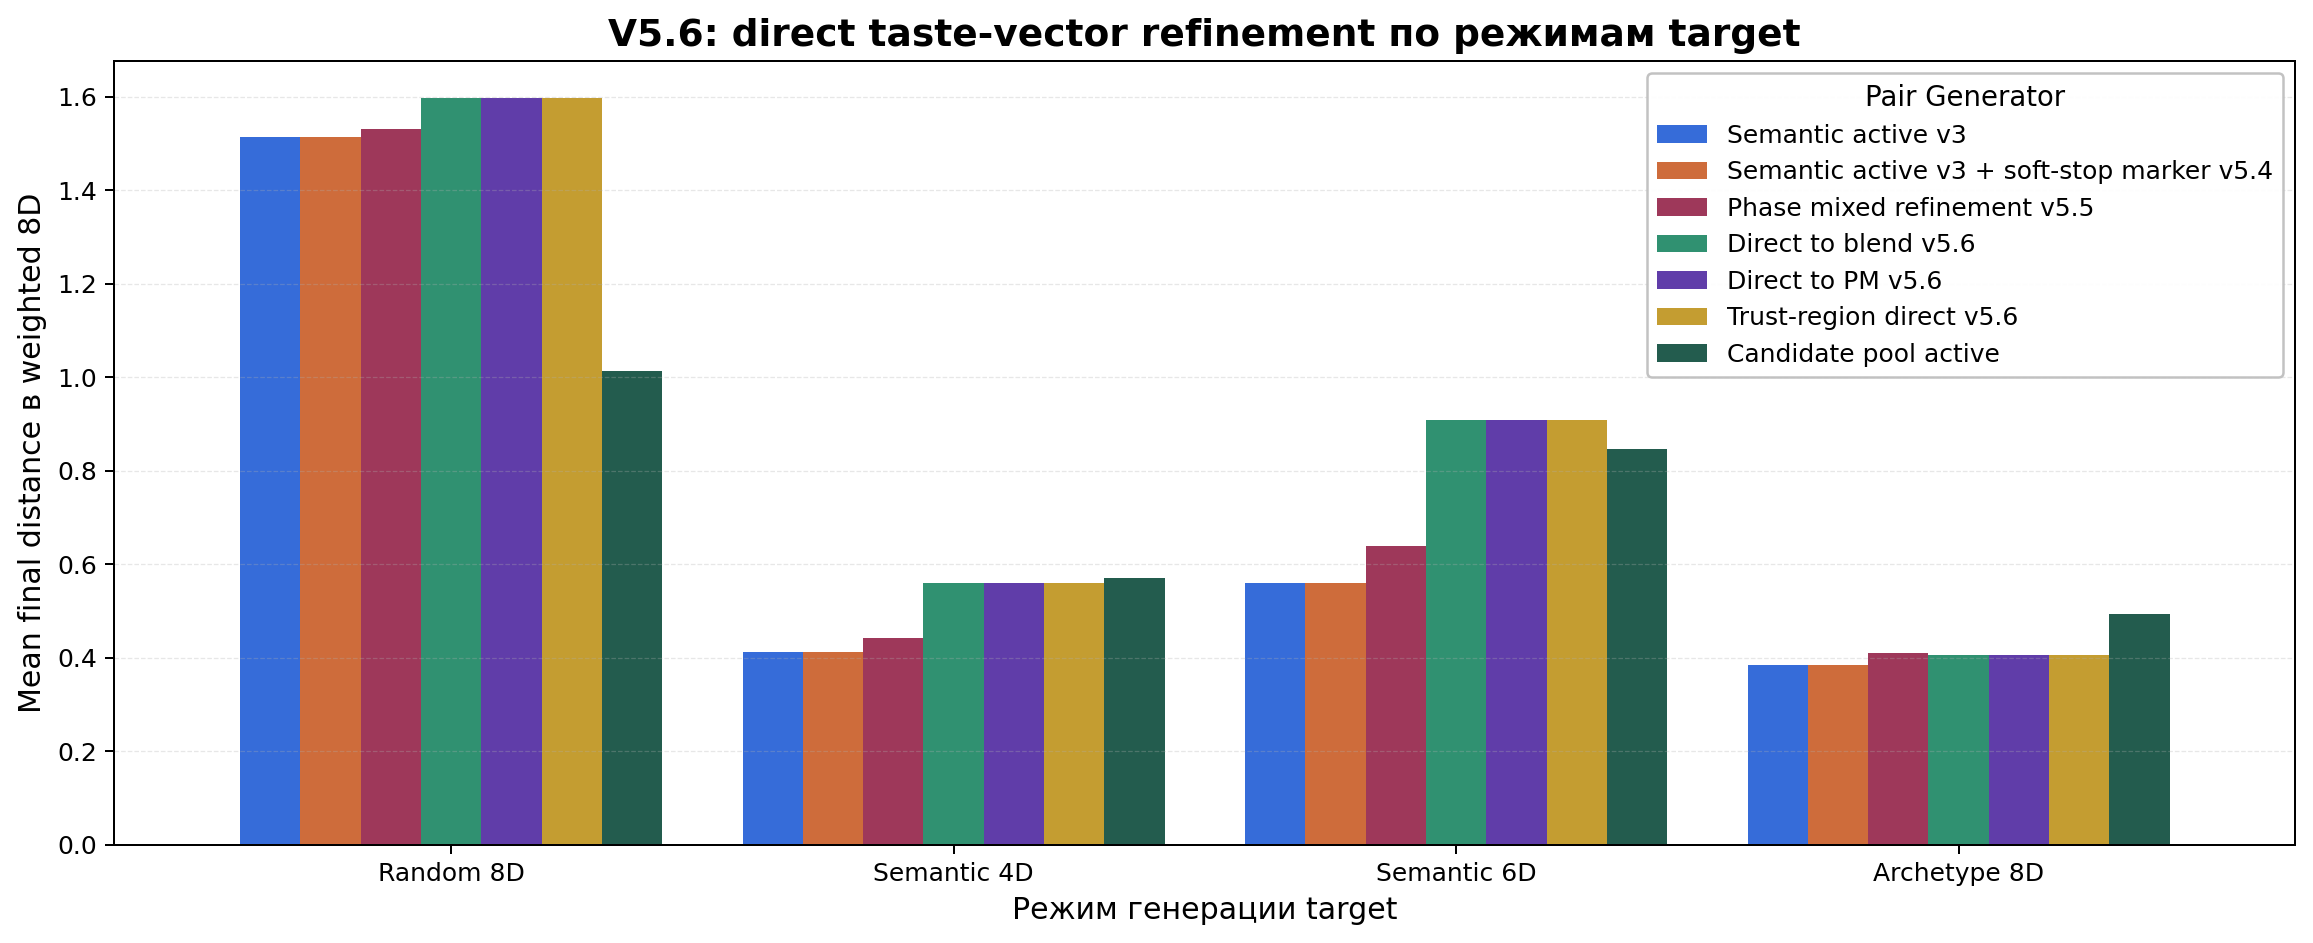

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_steps_before_after_soft_stop_archetype8d.png


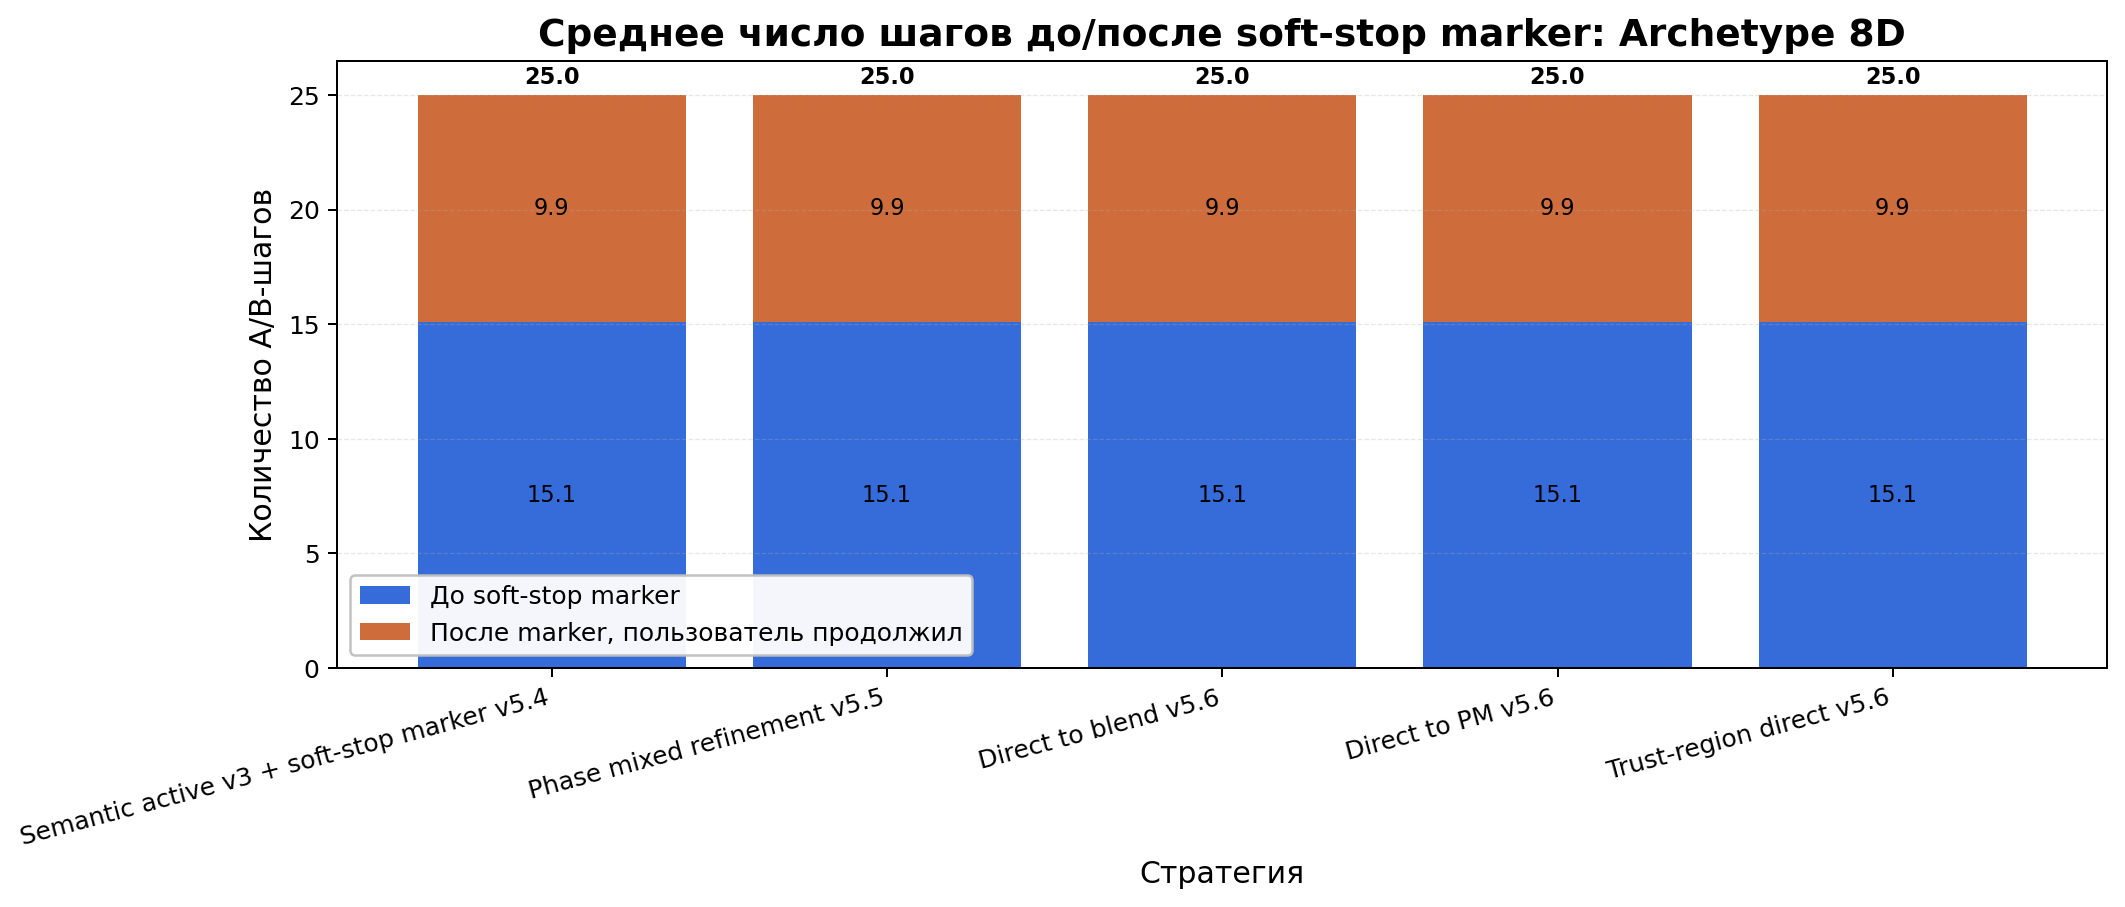

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_stop_vs_final_distance_archetype8d.png


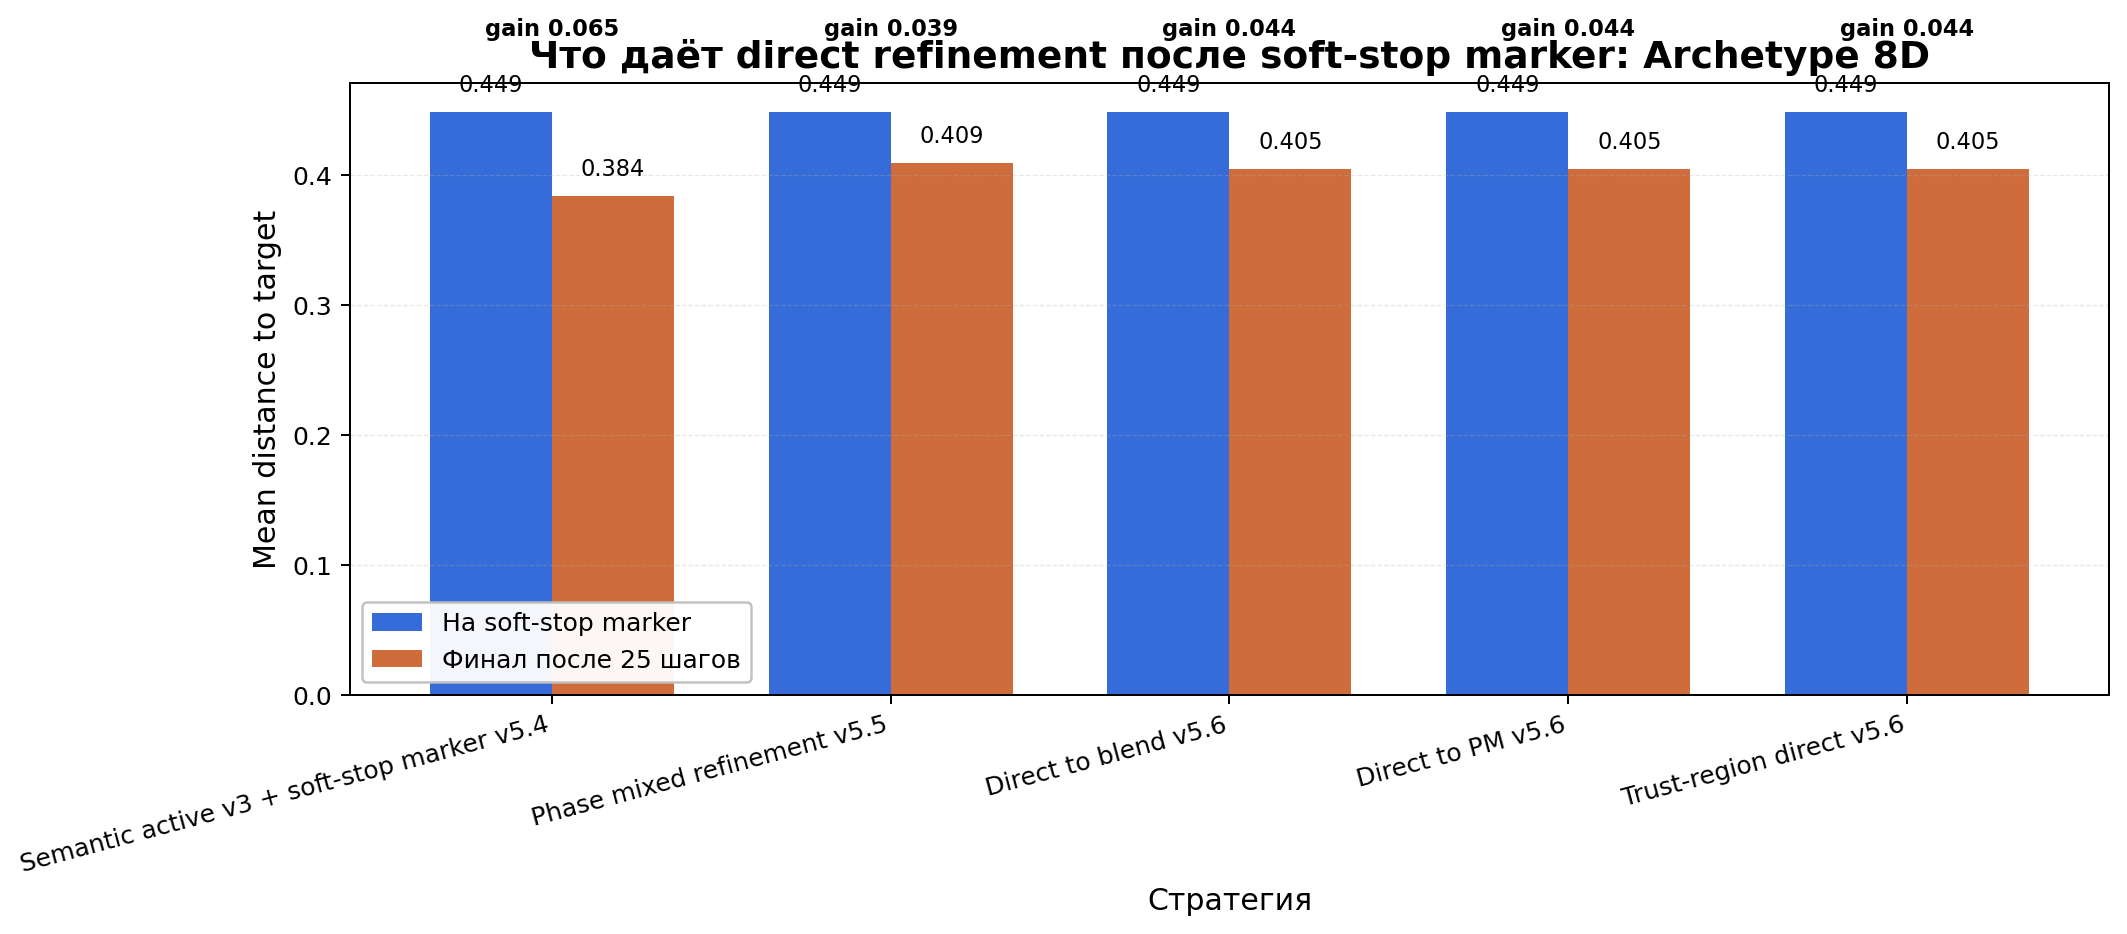

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_post_marker_source_usage_archetype8d.png


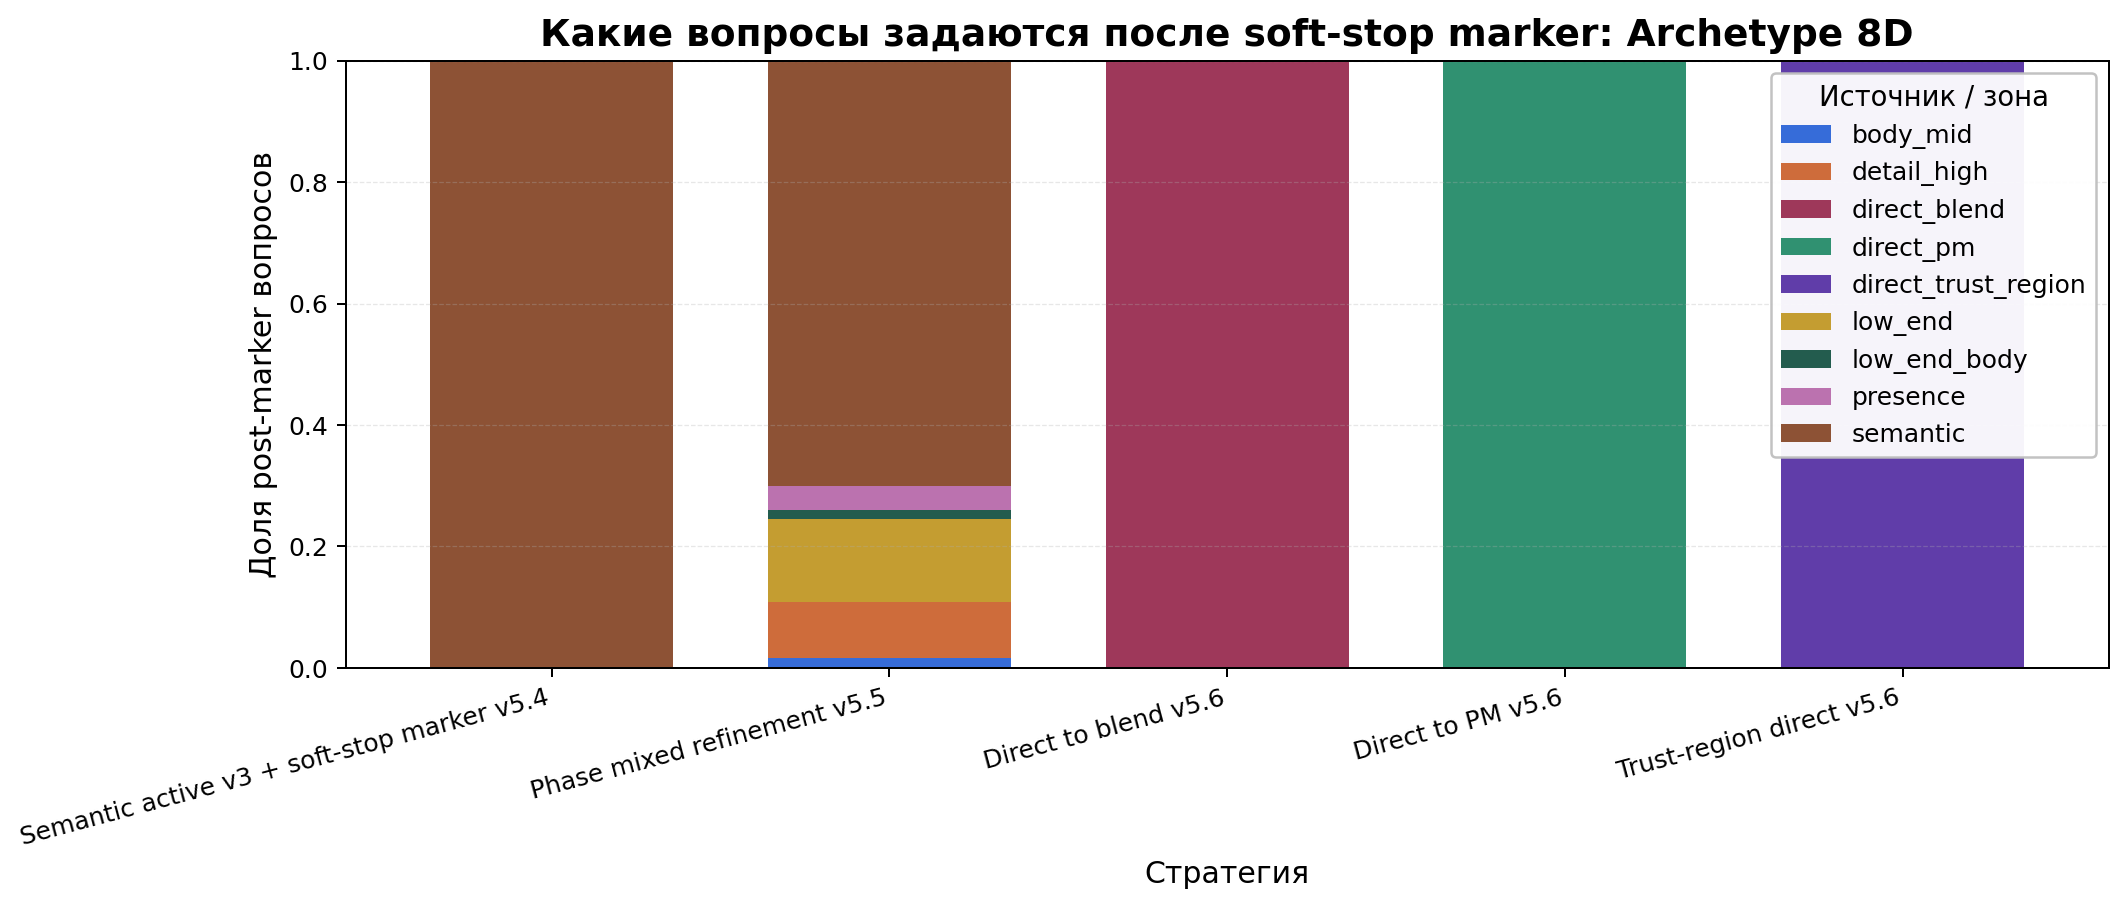

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_direct_selection_archetype8d.png


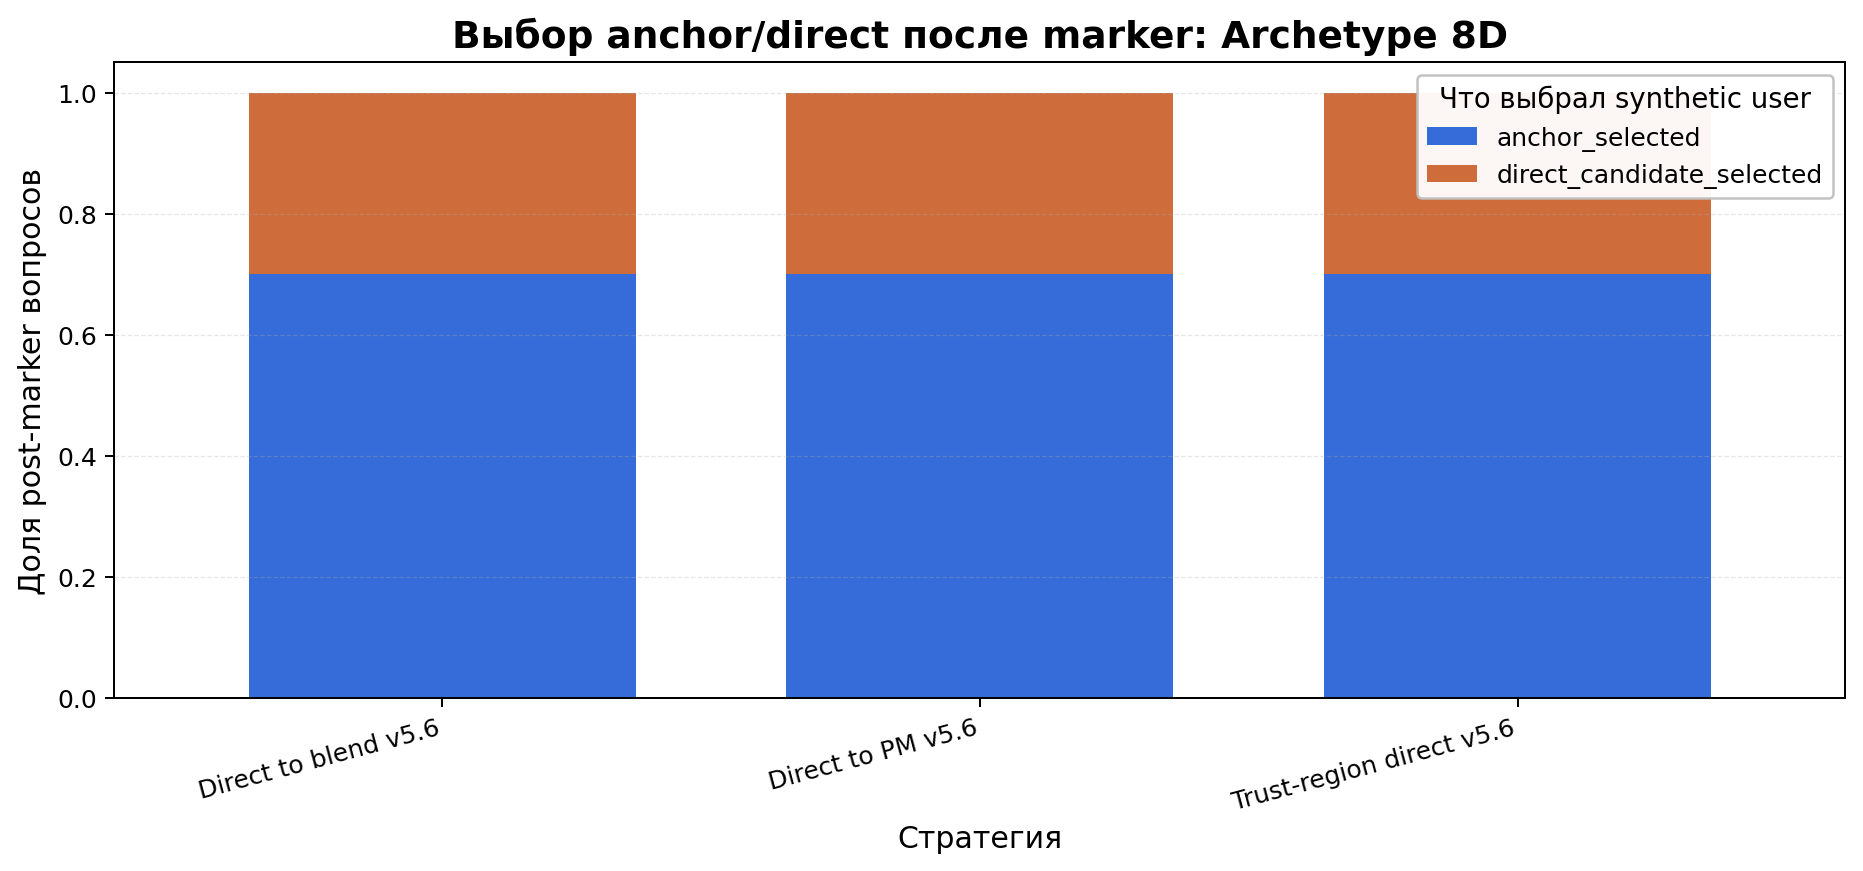

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_direct_vector_cosines_archetype8d.png


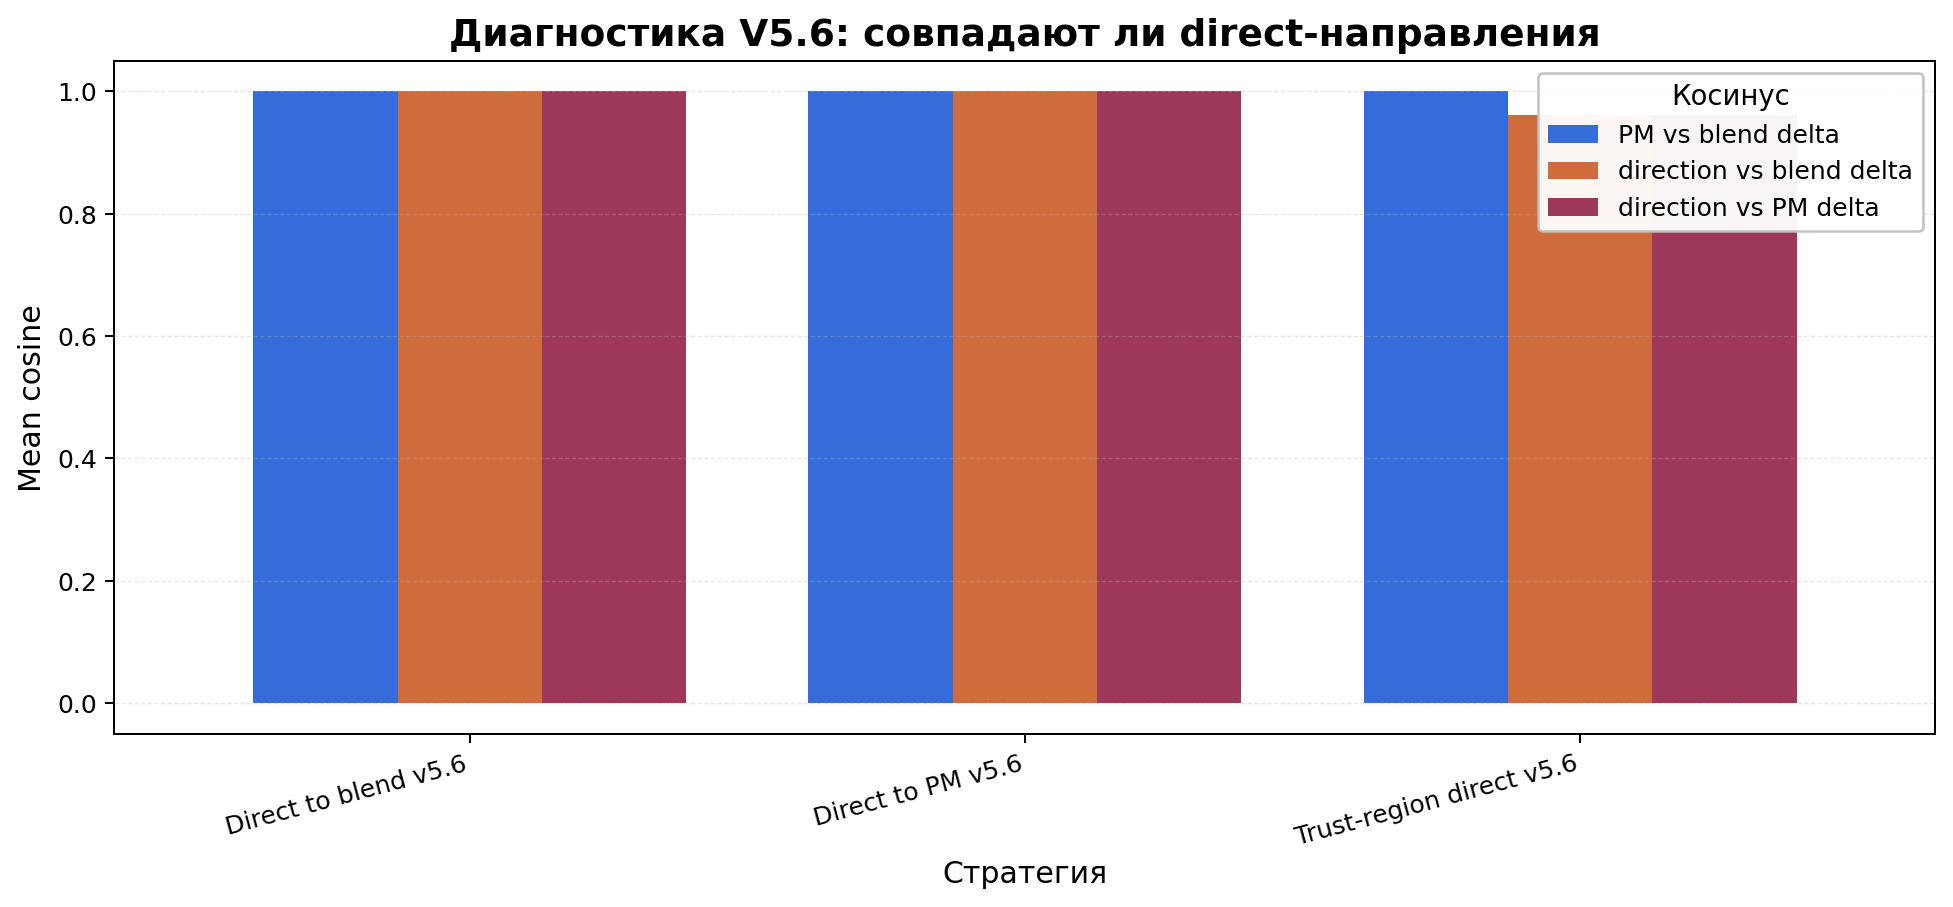

C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization\outputs\figures\article_v56_direct_taste_vector_refinement_direct_vector_norms_archetype8d.png


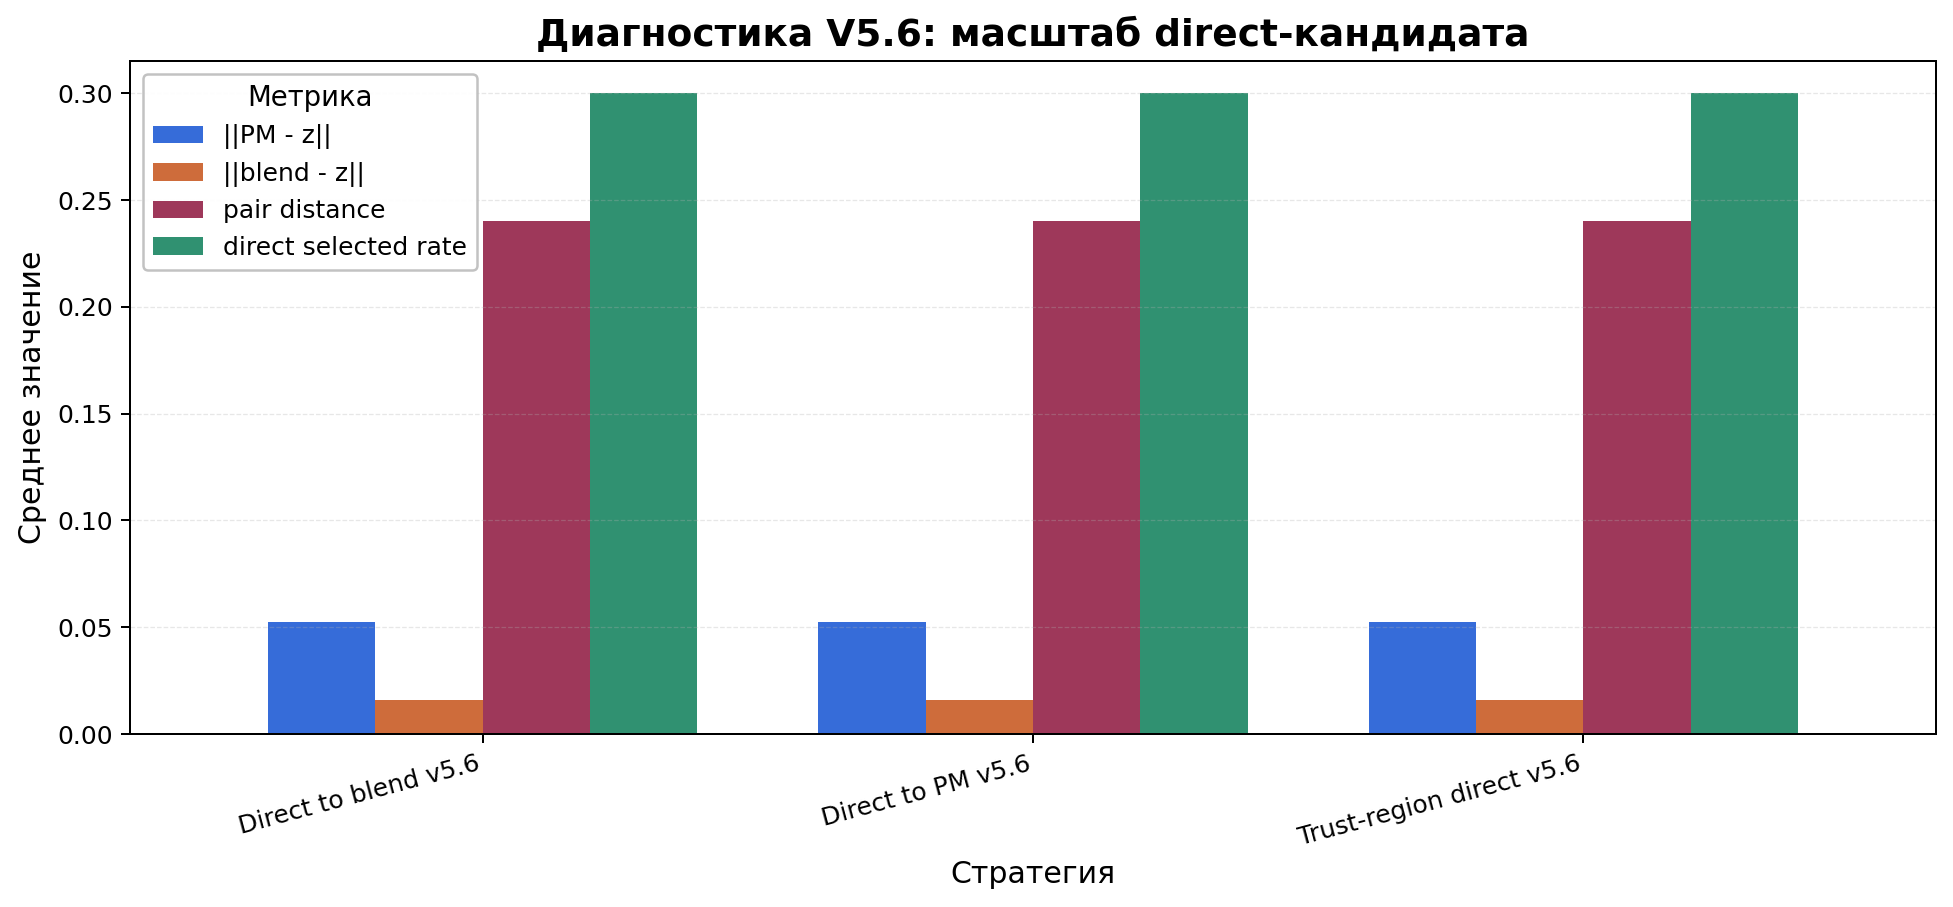

In [27]:
import importlib.util
from IPython.display import Image, display

# Загружаем функции построения графиков из experiment-файла.
# Через spec_from_file_location, потому что имя файла начинается с цифры.
exp_path = PROJECT_ROOT / 'experiments' / '20_direct_taste_vector_refinement.py'
spec = importlib.util.spec_from_file_location('v56_exp', exp_path)
v56_exp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(v56_exp)

# Строим и сохраняем графики.
v56_exp.plot_final_distance_by_target(summary, fig_dir, PREFIX)
v56_exp.plot_convergence_archetype(curves, summary, fig_dir, PREFIX)
v56_exp.plot_phase_step_budget(step_budget, fig_dir, PREFIX)
v56_exp.plot_stop_vs_final_distance(summary, fig_dir, PREFIX)
v56_exp.plot_post_marker_source_usage(post_marker_source_usage, fig_dir, PREFIX)
v56_exp.plot_direct_selection(direct_selection, fig_dir, PREFIX)
v56_exp.plot_direct_vector_cosines(direct_diagnostics, fig_dir, PREFIX)
v56_exp.plot_direct_vector_norms(direct_diagnostics, fig_dir, PREFIX)

figure_files = [
    f'{PREFIX}_convergence_archetype8d.png',
    f'{PREFIX}_mean_final_distance_by_target.png',
    f'{PREFIX}_steps_before_after_soft_stop_archetype8d.png',
    f'{PREFIX}_stop_vs_final_distance_archetype8d.png',
    f'{PREFIX}_post_marker_source_usage_archetype8d.png',
    f'{PREFIX}_direct_selection_archetype8d.png',
    f'{PREFIX}_direct_vector_cosines_archetype8d.png',
    f'{PREFIX}_direct_vector_norms_archetype8d.png',
]

for filename in figure_files:
    file_path = fig_dir / filename
    if file_path.exists():
        print(file_path)
        display(Image(filename=str(file_path)))
    else:
        print('Не найден график:', file_path)


V5.6 показал, что direct taste-vector candidate может быть полезным challenger:
synthetic user выбирает его примерно в 30% post-marker вопросов.

Но direct-направление, полученное из Preference Model / blend, оказалось почти идентичным для разных вариантов калибровки, поэтому direct-ветка не даёт отдельного преимущества относительно продолжения Semantic active v3.